# Notebook 2: Multiple Sequence Alignments and Evolutionary Information

**Series: Understanding AlphaFold2 from First Principles (2 of 8)**

---

## Objective

Understand how multiple sequence alignments encode structural information through coevolution, and why this is the foundation of AlphaFold2's input.

---

**Prerequisites:** Notebook 1 (Protein Structure Fundamentals)  
**Libraries:** numpy, matplotlib, scipy  
**Key concepts:** MSA, Shannon entropy, mutual information, coevolution, contact prediction, Potts model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import patches
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12})
np.random.seed(42)

print("All imports successful.")

All imports successful.


---

## 1. What is a Multiple Sequence Alignment?

A **Multiple Sequence Alignment (MSA)** is a collection of protein (or nucleic acid) sequences from different organisms, aligned so that corresponding positions in each sequence are placed in the same column. These sequences are **homologs** -- they share a common evolutionary ancestor and typically fold into similar three-dimensional structures.

Formally, an MSA is a matrix $\mathbf{M} \in \{1, \dots, q\}^{N \times L}$, where:

- $N$ is the number of sequences (the **depth** of the MSA),
- $L$ is the length of the alignment (number of columns/residue positions),
- $q$ is the alphabet size ($q = 20$ for standard amino acids, often $q = 21$ including gaps).

Each row $\mathbf{M}_k = (M_{k,1}, M_{k,2}, \dots, M_{k,L})$ represents one sequence, and each column $i$ collects all residues observed at alignment position $i$ across the family.

The first row is typically the **query sequence** -- the protein whose structure we wish to predict. The remaining rows are homologs retrieved by tools such as JackHMMER or HHblits from large sequence databases (UniRef, BFD, MGnify).

### Why MSAs matter

The central insight is that **evolution is a structure-aware process**. Mutations that disrupt the protein's fold are removed by natural selection. Therefore, the pattern of allowed and forbidden mutations across millions of years of evolution encodes information about the three-dimensional structure of the protein.

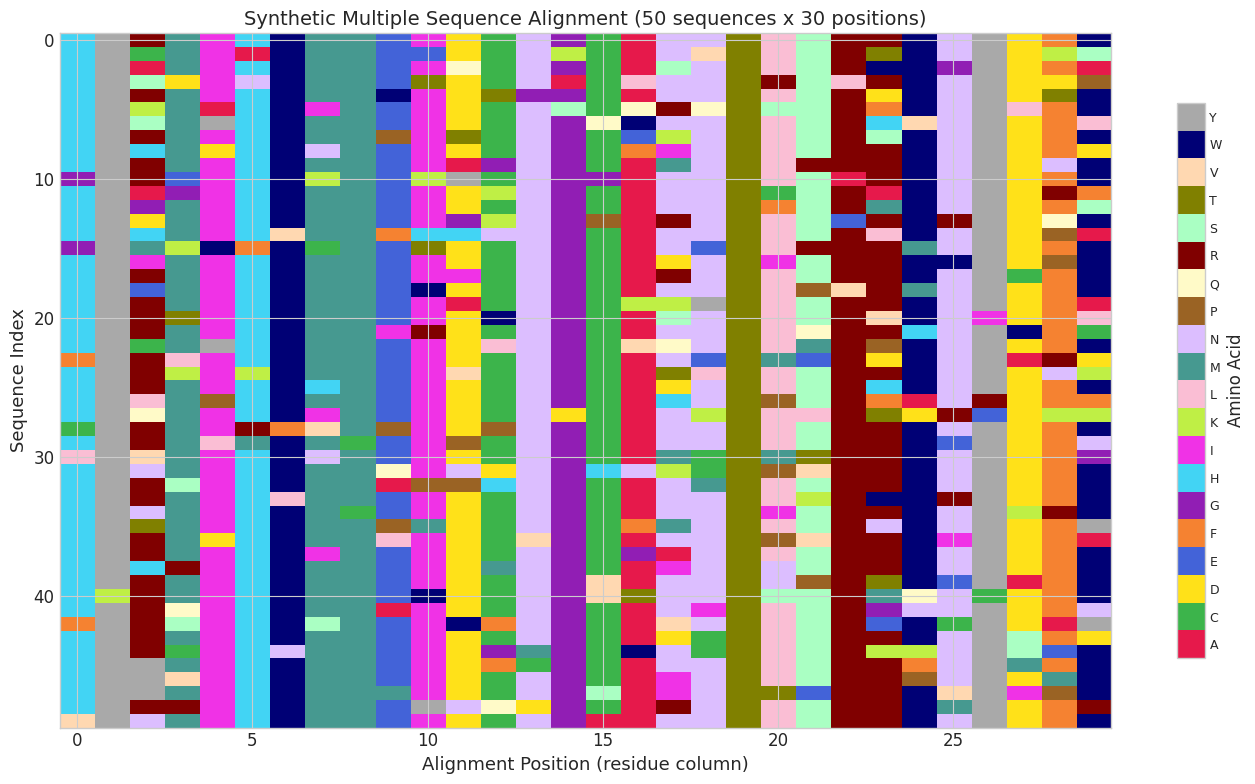

MSA shape: (50, 30)  (N_seq=50, L=30)
Query sequence: HYRMIHWMMEIDCNGCANNTLSRRWNYDFW


In [2]:
# --- Create a synthetic MSA matrix (50 sequences x 30 residues) ---
# We use integers 0-19 representing 20 amino acids.

N_seq = 50   # number of sequences (MSA depth)
L = 30       # alignment length (number of residue positions)
q = 20       # alphabet size (20 amino acids)

# Amino acid one-letter codes for labeling
AA_ALPHABET = list('ACDEFGHIKLMNPQRSTVWY')

# Generate a query sequence (row 0)
query_seq = np.random.randint(0, q, size=L)

# Generate homologs by mutating the query with position-dependent conservation.
# Some positions are highly conserved (low mutation rate), others are variable.
conservation = np.random.beta(2, 5, size=L)  # values in (0,1); lower = more conserved

msa = np.zeros((N_seq, L), dtype=int)
msa[0] = query_seq  # first row is the query

for k in range(1, N_seq):
    for i in range(L):
        if np.random.rand() < conservation[i]:
            # Mutate: pick a random different amino acid
            msa[k, i] = np.random.randint(0, q)
        else:
            # Conserve: keep the query residue
            msa[k, i] = query_seq[i]

# --- Visualize the MSA as a colored heatmap ---
# Build a custom colormap with 20 distinct colors for amino acids
base_colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4',
    '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000',
    '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9'
]
aa_cmap = mcolors.ListedColormap(base_colors, name='amino_acids')
bounds = np.arange(q + 1) - 0.5
aa_norm = mcolors.BoundaryNorm(bounds, q)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(msa, aspect='auto', cmap=aa_cmap, norm=aa_norm, interpolation='nearest')

ax.set_xlabel('Alignment Position (residue column)', fontsize=13)
ax.set_ylabel('Sequence Index', fontsize=13)
ax.set_title('Synthetic Multiple Sequence Alignment (50 sequences x 30 positions)', fontsize=14)

# Add a colorbar with amino acid labels
cbar = fig.colorbar(im, ax=ax, ticks=np.arange(q), shrink=0.8)
cbar.ax.set_yticklabels(AA_ALPHABET, fontsize=9)
cbar.set_label('Amino Acid', fontsize=12)

plt.tight_layout()
plt.show()

print(f"MSA shape: {msa.shape}  (N_seq={N_seq}, L={L})")
print(f"Query sequence: {''.join(AA_ALPHABET[a] for a in query_seq)}")

In the heatmap above, each row is a sequence and each column is an alignment position. Columns where most cells share the same color are **conserved** positions. Columns with a rainbow of colors are **variable** positions.

Notice that conservation is not uniform -- some positions tolerate many substitutions while others are locked to a single amino acid. This variability is not random; it reflects structural and functional constraints.

---

## 2. Sequence Conservation and Shannon Entropy

The most basic information we can extract from an MSA column is how **conserved** it is. We quantify this using **Shannon entropy**:

$$
H_i = -\sum_{a=1}^{q} f_{a,i} \log_2 f_{a,i}
$$

where $f_{a,i}$ is the frequency of amino acid $a$ at alignment position $i$, and we adopt the convention $0 \log_2 0 = 0$.

**Interpretation:**

- $H_i = 0$: position $i$ is **perfectly conserved** (only one amino acid type observed). This is the minimum possible entropy.
- $H_i = \log_2 q \approx 4.32$ (for $q=20$): position $i$ is **maximally variable** (all amino acids equally likely). This is the maximum possible entropy.

Highly conserved positions (low $H_i$) typically correspond to:

- **Catalytic residues** in enzyme active sites,
- **Structural residues** critical for the fold (e.g., glycines in tight turns, prolines in specific conformations),
- **Binding residues** involved in protein-protein or protein-ligand interactions.

Variable positions (high $H_i$) are usually on the protein surface and are not under strong selective pressure.

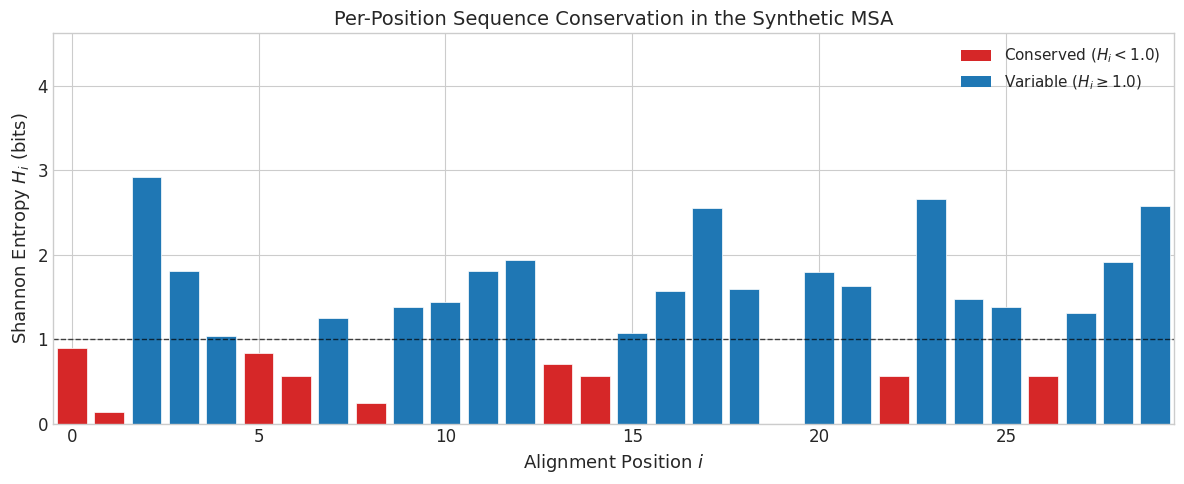

Conserved positions (H < 1.0): [ 0  1  5  6  8 13 14 19 22 26]
Min entropy: 0.000 bits at position 19
Max entropy: 2.917 bits at position 2
Max possible entropy (log2(20)): 4.322 bits


In [3]:
def compute_column_entropy(msa, q=20, pseudocount=1e-10):
    """
    Compute Shannon entropy (in bits) for each column of an MSA.
    
    Parameters
    ----------
    msa : ndarray, shape (N, L), integer-valued in {0, ..., q-1}
    q : int, alphabet size
    pseudocount : float, small value to avoid log(0)
    
    Returns
    -------
    entropy : ndarray, shape (L,)
    """
    N, L = msa.shape
    entropy = np.zeros(L)
    for i in range(L):
        # Count occurrences of each amino acid at position i
        counts = np.bincount(msa[:, i], minlength=q).astype(float)
        freqs = counts / N + pseudocount
        freqs = freqs / freqs.sum()  # re-normalize after pseudocount
        entropy[i] = -np.sum(freqs * np.log2(freqs))
    return entropy

entropy = compute_column_entropy(msa, q=q)

# --- Plot per-column entropy as a bar chart ---
fig, ax = plt.subplots(figsize=(12, 5))

threshold = 1.0
colors = ['#d62728' if h < threshold else '#1f77b4' for h in entropy]

bars = ax.bar(np.arange(L), entropy, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=threshold, color='black', linestyle='--', linewidth=1.0, alpha=0.7,
           label=f'Threshold $H = {threshold}$ bit')

ax.set_xlabel('Alignment Position $i$', fontsize=13)
ax.set_ylabel('Shannon Entropy $H_i$ (bits)', fontsize=13)
ax.set_title('Per-Position Sequence Conservation in the Synthetic MSA', fontsize=14)
ax.set_xlim(-0.5, L - 0.5)
ax.set_ylim(0, np.log2(q) + 0.3)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label=f'Conserved ($H_i < {threshold}$)'),
    Patch(facecolor='#1f77b4', label=f'Variable ($H_i \geq {threshold}$)'),
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

conserved_positions = np.where(entropy < threshold)[0]
print(f"Conserved positions (H < {threshold}): {conserved_positions}")
print(f"Min entropy: {entropy.min():.3f} bits at position {entropy.argmin()}")
print(f"Max entropy: {entropy.max():.3f} bits at position {entropy.argmax()}")
print(f"Max possible entropy (log2({q})): {np.log2(q):.3f} bits")

The red bars identify positions where entropy falls below 1.0 bit, indicating strong conservation. In a real protein family, these would be residues essential for structure or function.

However, conservation alone tells us only about individual positions. To learn about **spatial contacts** between residues, we need to study how positions change *together* -- this is **coevolution**.

---

## 3. Coevolution: When Positions Change Together

### The biological intuition

Consider two residues $i$ and $j$ that are far apart in the sequence but form a physical contact in the folded structure. If a mutation at position $i$ changes the size or charge of the side chain, then position $j$ must undergo a **compensatory mutation** to maintain the contact. Over evolutionary time, these correlated substitutions leave a statistical signature in the MSA.

### Mutual Information

The classical measure of pairwise correlation between MSA columns is **Mutual Information (MI)**:

$$
MI(i, j) = \sum_{a=1}^{q} \sum_{b=1}^{q} f_{ab}^{ij} \log_2 \frac{f_{ab}^{ij}}{f_a^i \cdot f_b^j}
$$

where:

- $f_{ab}^{ij}$ is the **joint frequency** of observing amino acid $a$ at position $i$ and amino acid $b$ at position $j$ in the same sequence,
- $f_a^i$ is the **marginal frequency** of amino acid $a$ at position $i$,
- $f_b^j$ is the **marginal frequency** of amino acid $b$ at position $j$.

MI measures the departure from independence: if positions $i$ and $j$ evolve independently, then $f_{ab}^{ij} = f_a^i \cdot f_b^j$ and $MI(i,j) = 0$. Positive MI indicates correlation.

### Simulating coevolution

Below we construct a synthetic MSA with **known** coevolving pairs, then compute the MI matrix to see if the signal is recoverable.

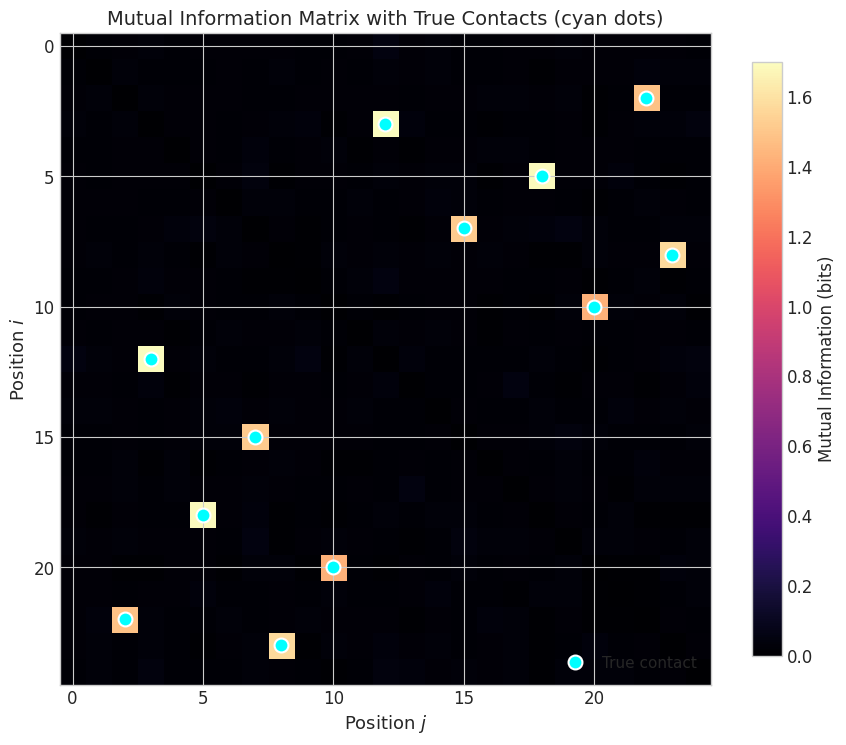

True contacts: [(2, 22), (5, 18), (7, 15), (10, 20), (3, 12), (8, 23)]
MI at true contacts: ['1.4811', '1.6911', '1.5168', '1.4262', '1.6992', '1.5698']
Mean MI (off-diagonal): 0.0533


In [4]:
# --- Create a synthetic MSA with known coevolving column pairs ---

N_seq_coev = 500   # need more sequences for reliable statistics
L_coev = 25        # alignment length
q_coev = 5         # smaller alphabet for clearer signal

# Define true contacting pairs (0-indexed)
true_contacts = [(2, 22), (5, 18), (7, 15), (10, 20), (3, 12), (8, 23)]

# Start with independent columns
msa_coev = np.random.randint(0, q_coev, size=(N_seq_coev, L_coev))

# Inject coevolution: for each true contact (i, j), make column j depend on column i.
# Specifically, j = permutation(i) with high probability.
for (ci, cj) in true_contacts:
    # Create a fixed permutation mapping for this pair
    perm = np.random.permutation(q_coev)
    for k in range(N_seq_coev):
        if np.random.rand() < 0.85:  # 85% of the time, apply the coupling
            msa_coev[k, cj] = perm[msa_coev[k, ci]]
        # else: random (noise)

def compute_mi_matrix(msa, q, pseudocount=1e-6):
    """
    Compute the Mutual Information matrix for all column pairs.
    
    Returns
    -------
    mi : ndarray, shape (L, L)
    """
    N, L = msa.shape
    mi = np.zeros((L, L))
    
    # Precompute marginal frequencies
    marginals = np.zeros((L, q))
    for i in range(L):
        counts = np.bincount(msa[:, i], minlength=q).astype(float)
        marginals[i] = (counts + pseudocount)
        marginals[i] /= marginals[i].sum()
    
    for i in range(L):
        for j in range(i + 1, L):
            # Joint frequency table
            joint = np.zeros((q, q))
            for k in range(N):
                joint[msa[k, i], msa[k, j]] += 1
            joint = (joint + pseudocount)
            joint /= joint.sum()
            
            # Mutual information
            for a in range(q):
                for b in range(q):
                    if joint[a, b] > 0:
                        mi[i, j] += joint[a, b] * np.log2(
                            joint[a, b] / (marginals[i, a] * marginals[j, b])
                        )
            mi[j, i] = mi[i, j]  # symmetric
    
    return mi

mi_matrix = compute_mi_matrix(msa_coev, q_coev)

# --- Visualize MI matrix with true contacts overlaid ---
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(mi_matrix, cmap='magma', interpolation='nearest', origin='upper')
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Mutual Information (bits)', fontsize=12)

# Overlay true contacts as white circles
for (ci, cj) in true_contacts:
    ax.plot(cj, ci, 'o', color='cyan', markersize=10, markeredgecolor='white',
            markeredgewidth=1.5, label='True contact' if ci == true_contacts[0][0] else '')
    ax.plot(ci, cj, 'o', color='cyan', markersize=10, markeredgecolor='white',
            markeredgewidth=1.5)

ax.set_xlabel('Position $j$', fontsize=13)
ax.set_ylabel('Position $i$', fontsize=13)
ax.set_title('Mutual Information Matrix with True Contacts (cyan dots)', fontsize=14)
ax.legend(fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()

print(f"True contacts: {true_contacts}")
print(f"MI at true contacts: {[f'{mi_matrix[i,j]:.4f}' for (i,j) in true_contacts]}")
print(f"Mean MI (off-diagonal): {mi_matrix[np.triu_indices(L_coev, k=1)].mean():.4f}")

The MI matrix shows bright spots at the positions where we injected coevolutionary coupling (cyan dots). However, notice that there is also **background noise** -- some non-contact pairs show moderate MI values. This is a well-known limitation of raw MI, and we will address it in the next section.

---

## 4. From Coevolution to Contact Maps

### The problem with raw Mutual Information

Raw MI suffers from two major biases:

1. **Phylogenetic bias:** Closely related sequences are not independent observations. They share correlated mutations simply because of shared ancestry, not because of structural contacts.

2. **Transitive (indirect) correlations:** If position $i$ contacts position $j$, and position $j$ contacts position $k$, then MI will also detect a correlation between $i$ and $k$ -- even though they may not be in direct contact. MI cannot distinguish **direct** from **indirect** couplings.

### Average Product Correction (APC)

A simple but effective fix for the background noise in MI is the **Average Product Correction (APC)** introduced by Dunn et al. (2008). The corrected MI is:

$$
MI_{\text{APC}}(i, j) = MI(i, j) - \frac{\overline{MI_i} \cdot \overline{MI_j}}{\overline{MI}}
$$

where:

- $\overline{MI_i} = \frac{1}{L-1} \sum_{k \neq i} MI(i, k)$ is the mean MI of row $i$,
- $\overline{MI_j} = \frac{1}{L-1} \sum_{k \neq j} MI(j, k)$ is the mean MI of row $j$,
- $\overline{MI} = \frac{2}{L(L-1)} \sum_{i < j} MI(i, j)$ is the global mean MI.

APC removes the expected background under a null model where each position contributes independently to the background MI.

### Direct Coupling Analysis and the Potts Model

A more principled approach is **Direct Coupling Analysis (DCA)**, which fits a **Potts model** (maximum entropy model) to the MSA:

$$
P(\mathbf{s}) = \frac{1}{Z} \exp\left(\sum_{i=1}^{L} h_i(s_i) + \sum_{i < j} J_{ij}(s_i, s_j)\right)
$$

where:

- $\mathbf{s} = (s_1, s_2, \dots, s_L)$ is a sequence,
- $h_i(s_i) \in \mathbb{R}$ are **fields** (single-site biases),
- $J_{ij}(s_i, s_j) \in \mathbb{R}^{q \times q}$ are **couplings** (pairwise interaction parameters),
- $Z = \sum_{\mathbf{s}} \exp(\cdots)$ is the partition function.

The key idea: the couplings $J_{ij}$ capture **direct** statistical dependencies, factoring out indirect effects. The Frobenius norm of $J_{ij}$,

$$
\|J_{ij}\|_F = \sqrt{\sum_{a,b} J_{ij}(a,b)^2},
$$

is used as a score for predicting whether residues $i$ and $j$ are in physical contact.

Methods like **plmDCA** (pseudo-likelihood maximization DCA) and **GREMLIN** (Generative REgularized ModeLs of proteINs) efficiently approximate the Potts model parameters. These were the state-of-the-art contact predictors before deep learning.

For this notebook, we will demonstrate the APC correction and its dramatic effect on cleaning up the MI signal.

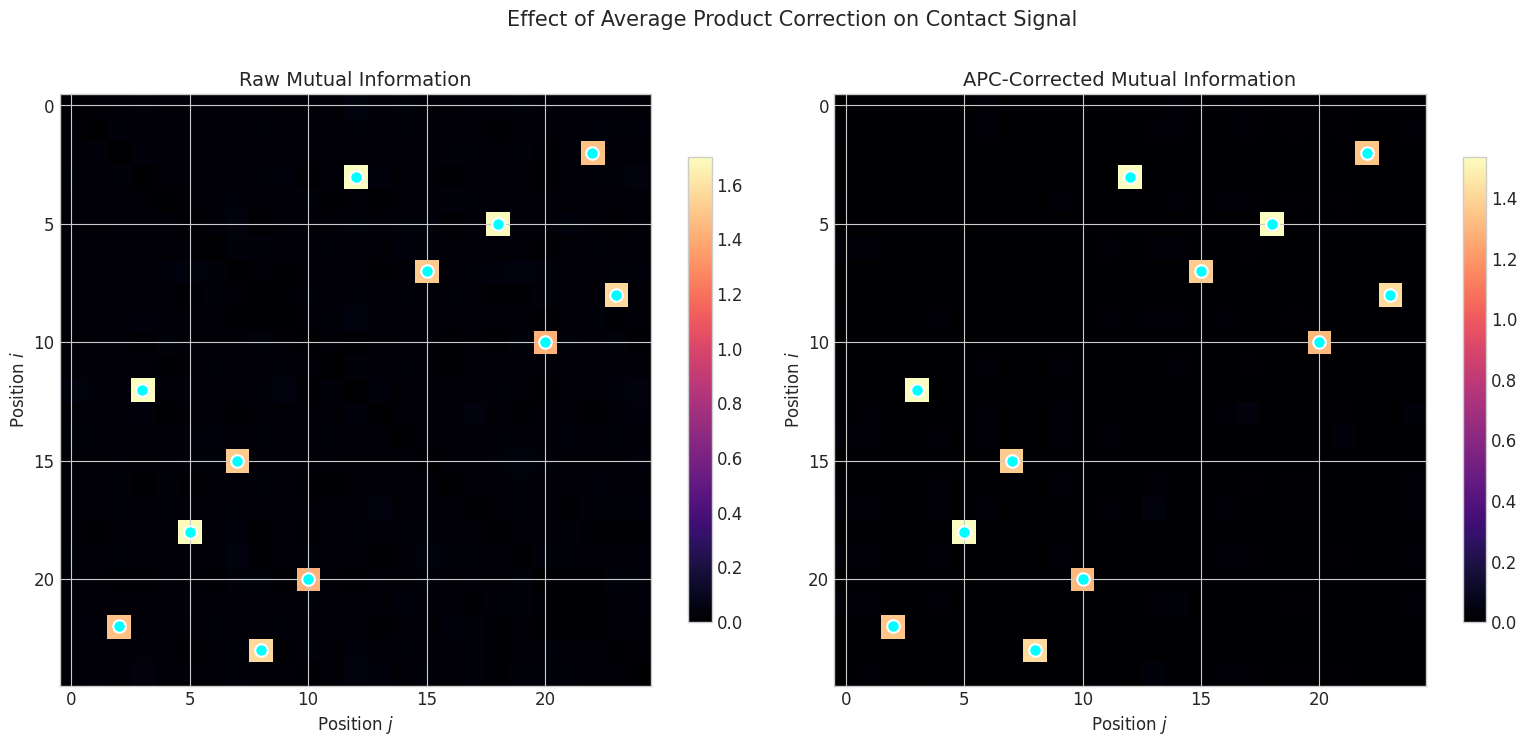


Raw MI -- top 6 predictions:
  Rank 1: pair (3, 12) = 1.6992  <-- TRUE CONTACT
  Rank 2: pair (5, 18) = 1.6911  <-- TRUE CONTACT
  Rank 3: pair (8, 23) = 1.5698  <-- TRUE CONTACT
  Rank 4: pair (7, 15) = 1.5168  <-- TRUE CONTACT
  Rank 5: pair (2, 22) = 1.4811  <-- TRUE CONTACT
  Rank 6: pair (10, 20) = 1.4262  <-- TRUE CONTACT
  Precision@6: 6/6

APC-corrected MI -- top 6 predictions:
  Rank 1: pair (5, 18) = 1.5374  <-- TRUE CONTACT
  Rank 2: pair (3, 12) = 1.5335  <-- TRUE CONTACT
  Rank 3: pair (8, 23) = 1.4254  <-- TRUE CONTACT
  Rank 4: pair (7, 15) = 1.3770  <-- TRUE CONTACT
  Rank 5: pair (2, 22) = 1.3532  <-- TRUE CONTACT
  Rank 6: pair (10, 20) = 1.3113  <-- TRUE CONTACT
  Precision@6: 6/6


In [5]:
def apply_apc(mi):
    """
    Apply the Average Product Correction (APC) to a mutual information matrix.
    
    Parameters
    ----------
    mi : ndarray, shape (L, L), symmetric MI matrix with zero diagonal.
    
    Returns
    -------
    mi_apc : ndarray, shape (L, L), APC-corrected MI matrix.
    """
    L = mi.shape[0]
    
    # Mean MI for each row (excluding diagonal)
    row_means = np.zeros(L)
    for i in range(L):
        row_means[i] = np.sum(mi[i]) / (L - 1)  # diagonal is zero, so sum excludes self
    
    # Global mean MI (upper triangle only)
    upper_indices = np.triu_indices(L, k=1)
    global_mean = np.mean(mi[upper_indices])
    
    # APC correction
    mi_apc = np.zeros_like(mi)
    for i in range(L):
        for j in range(i + 1, L):
            correction = (row_means[i] * row_means[j]) / global_mean if global_mean > 0 else 0
            mi_apc[i, j] = mi[i, j] - correction
            mi_apc[j, i] = mi_apc[i, j]
    
    return mi_apc

mi_apc = apply_apc(mi_matrix)

# --- Side-by-side comparison: raw MI vs. APC-corrected MI ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Raw MI
ax = axes[0]
im0 = ax.imshow(mi_matrix, cmap='magma', interpolation='nearest', origin='upper')
for (ci, cj) in true_contacts:
    ax.plot(cj, ci, 'o', color='cyan', markersize=9, markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(ci, cj, 'o', color='cyan', markersize=9, markeredgecolor='white', markeredgewidth=1.5)
fig.colorbar(im0, ax=ax, shrink=0.75)
ax.set_title('Raw Mutual Information', fontsize=14)
ax.set_xlabel('Position $j$', fontsize=12)
ax.set_ylabel('Position $i$', fontsize=12)

# APC-corrected MI
ax = axes[1]
vmax_apc = np.percentile(mi_apc[mi_apc > 0], 99) if np.any(mi_apc > 0) else 1.0
im1 = ax.imshow(mi_apc, cmap='magma', interpolation='nearest', origin='upper',
                vmin=0, vmax=vmax_apc)
for (ci, cj) in true_contacts:
    ax.plot(cj, ci, 'o', color='cyan', markersize=9, markeredgecolor='white', markeredgewidth=1.5)
    ax.plot(ci, cj, 'o', color='cyan', markersize=9, markeredgecolor='white', markeredgewidth=1.5)
fig.colorbar(im1, ax=ax, shrink=0.75)
ax.set_title('APC-Corrected Mutual Information', fontsize=14)
ax.set_xlabel('Position $j$', fontsize=12)
ax.set_ylabel('Position $i$', fontsize=12)

plt.suptitle('Effect of Average Product Correction on Contact Signal',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# --- Quantify improvement ---
# Rank all pairs by score; check where true contacts land
upper_idx = np.triu_indices(L_coev, k=1)
pairs = list(zip(upper_idx[0], upper_idx[1]))
true_set = set(true_contacts)

for label, matrix in [('Raw MI', mi_matrix), ('APC-corrected MI', mi_apc)]:
    scores = matrix[upper_idx]
    ranked = np.argsort(-scores)  # descending
    print(f"\n{label} -- top {len(true_contacts)} predictions:")
    n_correct = 0
    for rank in range(len(true_contacts)):
        p = pairs[ranked[rank]]
        is_true = p in true_set or (p[1], p[0]) in true_set
        n_correct += is_true
        print(f"  Rank {rank+1}: pair ({p[0]}, {p[1]}) = {scores[ranked[rank]]:.4f}"
              f"  {'<-- TRUE CONTACT' if is_true else ''}")
    print(f"  Precision@{len(true_contacts)}: {n_correct}/{len(true_contacts)}")

The APC correction dramatically sharpens the signal. In the right panel, the true contacts (cyan dots) stand out much more clearly against the background, and the top-ranked pairs are predominantly true contacts. This demonstrates why APC was a critical advance for coevolution-based contact prediction.

For even better performance, full DCA/Potts model methods disentangle direct from indirect couplings, but the principle is the same: extract the pairwise statistical structure hidden in the MSA.

---

## 5. From Contact Maps to 3D Structure

A **contact map** is a binary symmetric matrix $C \in \{0, 1\}^{L \times L}$ where $C_{ij} = 1$ if residues $i$ and $j$ are within a distance threshold (typically 8 Angstroms between $C_\beta$ atoms) in the 3D structure.

Given a sufficient number of contacts, it is possible to reconstruct an approximate 3D structure using **distance geometry**. The idea is to define an energy function that penalizes violations of the contact constraints and then minimize it:

$$
E(\mathbf{X}) = \sum_{(i,j) \in \text{contacts}} \frac{1}{2} k \left( d_{ij}(\mathbf{X}) - d_0 \right)^2 \cdot \mathbf{1}[d_{ij} > d_0] + \sum_{(i,j) \notin \text{contacts}} \frac{1}{2} k_r \left( d_0^r - d_{ij}(\mathbf{X}) \right)^2 \cdot \mathbf{1}[d_{ij} < d_0^r]
$$

where $d_{ij}(\mathbf{X}) = \|\mathbf{x}_i - \mathbf{x}_j\|$ is the Euclidean distance between residues $i$ and $j$, $d_0$ is the target contact distance, and $d_0^r$ is a repulsive distance for non-contacts.

Below we construct a synthetic contact map for a small protein with an alpha-helix and a beta-hairpin, then reconstruct an approximate 3D structure using energy minimization.

Running energy minimization (this may take a moment)...
Optimization finished. Final energy: 290.49
Converged: False


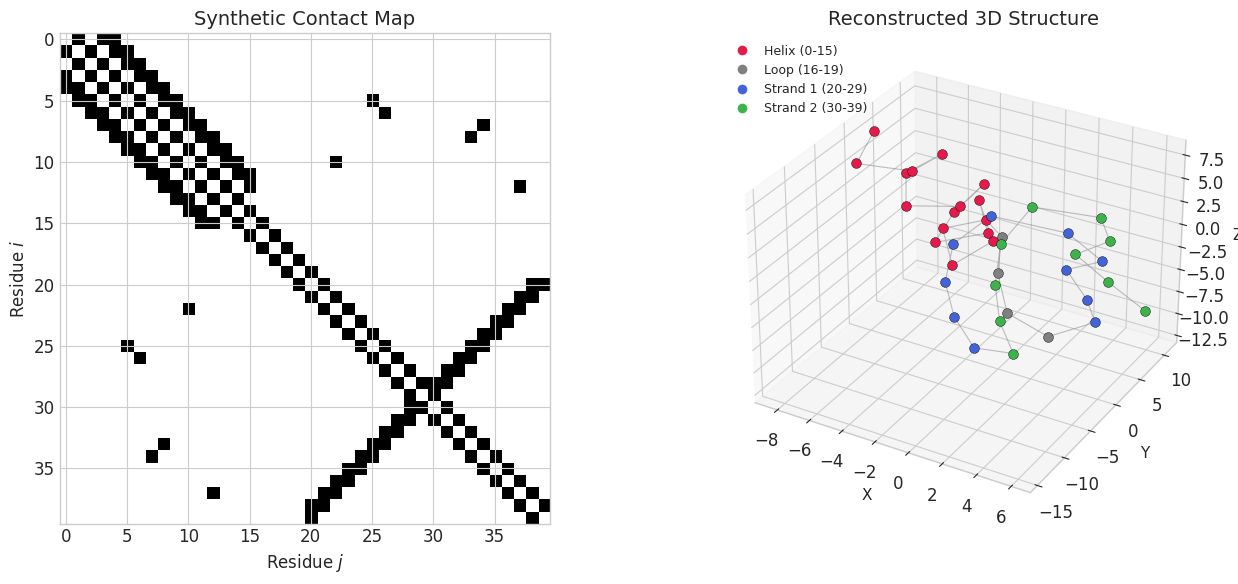

In [6]:
# --- Construct a synthetic contact map ---
# Protein: 40 residues
#   Residues 0-15: alpha helix (contacts at i,i+3 and i,i+4)
#   Residues 20-39: beta hairpin (two anti-parallel strands: 20-29 and 30-39)
#   Some contacts between the helix and beta sheet

L_struct = 40
contact_map = np.zeros((L_struct, L_struct), dtype=int)

# Sequential contacts (backbone: i, i+1)
for i in range(L_struct - 1):
    contact_map[i, i+1] = 1
    contact_map[i+1, i] = 1

# Alpha helix contacts: i, i+3 and i, i+4
for i in range(0, 16):
    for d in [3, 4]:
        j = i + d
        if j < 16:
            contact_map[i, j] = 1
            contact_map[j, i] = 1

# Beta hairpin: anti-parallel contacts between strand1 (20-29) and strand2 (30-39)
# Anti-parallel: residue 20+k contacts residue 39-k
for k in range(10):
    i_s = 20 + k
    j_s = 39 - k
    contact_map[i_s, j_s] = 1
    contact_map[j_s, i_s] = 1
    # Also nearby contacts in the sheet
    if j_s - 1 >= 30:
        contact_map[i_s, j_s - 1] = 1
        contact_map[j_s - 1, i_s] = 1

# Helix-sheet contacts (tertiary contacts)
tertiary_contacts = [(5, 25), (6, 26), (7, 34), (8, 33), (10, 22), (12, 37)]
for (i, j) in tertiary_contacts:
    contact_map[i, j] = 1
    contact_map[j, i] = 1

# --- Energy minimization to reconstruct 3D coordinates ---
def structure_energy(coords_flat, contact_map, d_contact=4.0, d_repulse=8.0,
                     k_contact=5.0, k_repulse=0.5, k_chain=10.0, d_chain=3.8):
    """
    Compute the energy of a structure given a contact map.
    
    - Contacts: attractive harmonic potential pulling pairs to d_contact.
    - Non-contacts: repulsive potential pushing pairs apart if closer than d_repulse.
    - Chain: harmonic bond between consecutive residues at d_chain (3.8 A = CA-CA).
    """
    L = contact_map.shape[0]
    coords = coords_flat.reshape(L, 3)
    energy = 0.0
    
    # Chain connectivity
    for i in range(L - 1):
        d = np.linalg.norm(coords[i] - coords[i + 1])
        energy += k_chain * (d - d_chain) ** 2
    
    # Contact and repulsive terms
    for i in range(L):
        for j in range(i + 2, L):  # skip i,i+1 (handled by chain)
            d = np.linalg.norm(coords[i] - coords[j])
            if contact_map[i, j] == 1:
                # Attractive: want d close to d_contact
                energy += k_contact * (d - d_contact) ** 2
            else:
                # Repulsive: push apart if too close
                if d < d_repulse:
                    energy += k_repulse * (d_repulse - d) ** 2
    
    return energy

# Initialize with random coordinates
np.random.seed(123)
x0 = np.random.randn(L_struct * 3) * 5.0

print("Running energy minimization (this may take a moment)...")
result = minimize(
    structure_energy,
    x0,
    args=(contact_map,),
    method='L-BFGS-B',
    options={'maxiter': 2000, 'ftol': 1e-10}
)

coords_opt = result.x.reshape(L_struct, 3)
print(f"Optimization finished. Final energy: {result.fun:.2f}")
print(f"Converged: {result.success}")

# --- Plot the reconstructed 3D structure ---
fig = plt.figure(figsize=(14, 6))

# Left: contact map
ax1 = fig.add_subplot(121)
ax1.imshow(contact_map, cmap='Greys', interpolation='nearest', origin='upper')
ax1.set_xlabel('Residue $j$', fontsize=12)
ax1.set_ylabel('Residue $i$', fontsize=12)
ax1.set_title('Synthetic Contact Map', fontsize=14)

# Right: 3D structure
ax2 = fig.add_subplot(122, projection='3d')

# Color by region
colors_struct = []
for i in range(L_struct):
    if i <= 15:
        colors_struct.append('#e6194b')   # helix = red
    elif i <= 19:
        colors_struct.append('#808080')   # loop = grey
    elif i <= 29:
        colors_struct.append('#4363d8')   # strand 1 = blue
    else:
        colors_struct.append('#3cb44b')   # strand 2 = green

# Plot backbone trace
ax2.plot(coords_opt[:, 0], coords_opt[:, 1], coords_opt[:, 2],
         '-', color='gray', linewidth=0.8, alpha=0.5)

# Plot CA atoms colored by region
for i in range(L_struct):
    ax2.scatter(coords_opt[i, 0], coords_opt[i, 1], coords_opt[i, 2],
               c=colors_struct[i], s=50, edgecolors='black', linewidths=0.3, zorder=5)

ax2.set_xlabel('X', fontsize=11)
ax2.set_ylabel('Y', fontsize=11)
ax2.set_zlabel('Z', fontsize=11)
ax2.set_title('Reconstructed 3D Structure', fontsize=14)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e6194b', markersize=8, label='Helix (0-15)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#808080', markersize=8, label='Loop (16-19)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4363d8', markersize=8, label='Strand 1 (20-29)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3cb44b', markersize=8, label='Strand 2 (30-39)'),
]
ax2.legend(handles=legend_elements, fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

The left panel shows the synthetic contact map encoding an alpha-helix (diagonal band in upper-left), a beta-hairpin (anti-diagonal band in lower-right), and some tertiary contacts between them. The right panel shows the approximate 3D structure reconstructed by energy minimization from those contacts alone.

This illustrates the key principle: **a sufficiently informative contact map determines the 3D fold**. The entire enterprise of coevolution-based structure prediction rests on this fact. AlphaFold2 takes this further by learning to predict accurate inter-residue **distance distributions** (not just binary contacts) from MSA features.

---

## 6. How AlphaFold2 Uses MSAs

AlphaFold2 represents the MSA as a **3D tensor** and processes it with a specialized neural network architecture called the **Evoformer**. Here we describe the key representations.

### MSA Representation

The MSA is encoded as a tensor of shape:

$$
\mathbf{M} \in \mathbb{R}^{N_{\text{seq}} \times N_{\text{res}} \times c_m}
$$

where:

- $N_{\text{seq}}$ is the number of sequences (MSA depth, typically capped at 512 in the Evoformer),
- $N_{\text{res}}$ is the number of residue positions (alignment length),
- $c_m = 256$ is the embedding dimension per position per sequence.

Each element $\mathbf{M}_{s,i} \in \mathbb{R}^{256}$ is a learned embedding of the amino acid identity at position $i$ in sequence $s$, enriched with positional features.

### Pair Representation

The pair representation is a tensor:

$$
\mathbf{Z} \in \mathbb{R}^{N_{\text{res}} \times N_{\text{res}} \times c_z}
$$

with $c_z = 128$. It is initialized partly from the **outer product mean** of MSA features:

$$
Z_{ij} \leftarrow Z_{ij} + \text{Linear}\left(\frac{1}{N_{\text{seq}}} \sum_{s=1}^{N_{\text{seq}}} \mathbf{m}_{s,i} \otimes \mathbf{m}_{s,j}\right)
$$

This is how coevolutionary information from the MSA flows into the pair representation.

### Evoformer Attention Patterns

The Evoformer applies two types of attention to the MSA representation:

- **Row-wise (within-sequence) attention**: each sequence attends to all positions within itself. This captures within-sequence dependencies and is biased by the pair representation.
- **Column-wise (cross-sequence) attention**: each position attends across all sequences at that position. This allows the network to learn patterns of covariation directly.

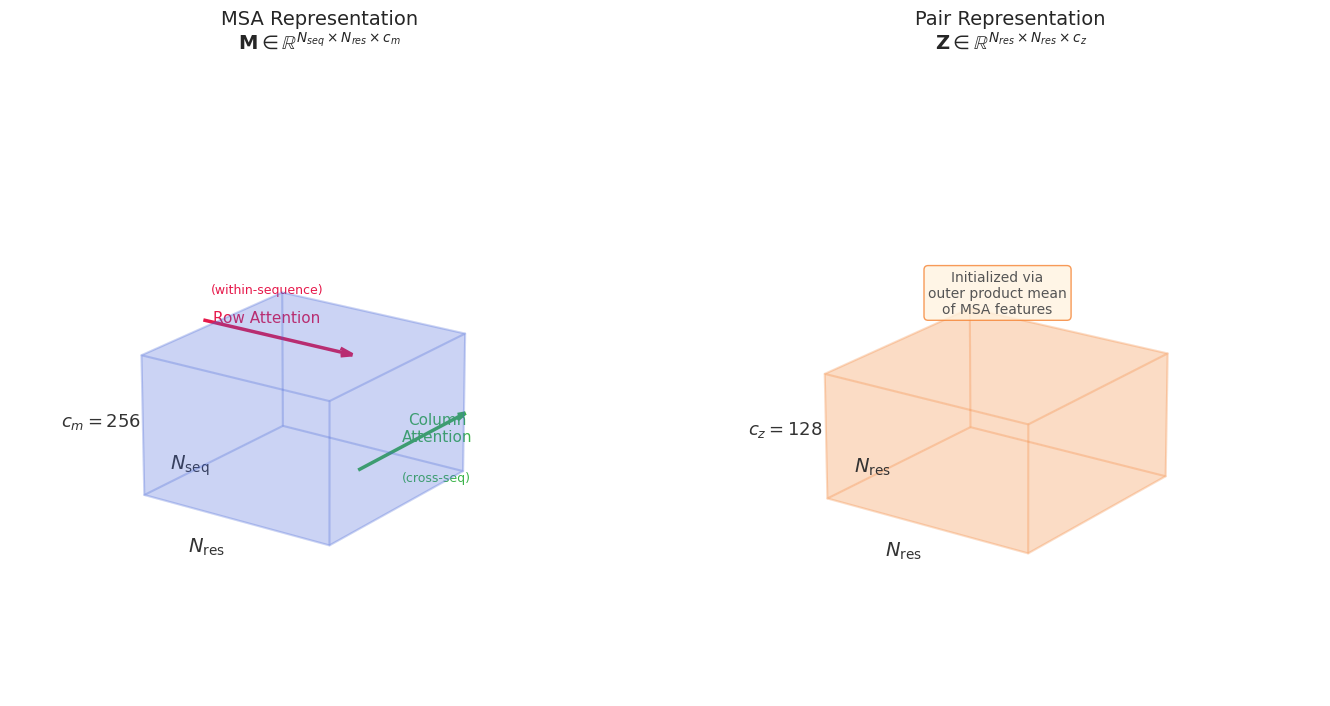

MSA Representation: shape (N_seq, N_res, 256) -- one 256-dim vector per amino acid per sequence
Pair Representation: shape (N_res, N_res, 128) -- one 128-dim vector per residue pair

Row attention operates along the N_res axis (within each sequence).
Column attention operates along the N_seq axis (across sequences at each position).


In [7]:
# --- Schematic diagram of the MSA tensor and Pair representation ---

fig = plt.figure(figsize=(14, 7))

# --- Left: MSA Representation as a 3D block ---
ax1 = fig.add_subplot(121, projection='3d')

# Draw a transparent rectangular box for the MSA tensor
# Dimensions: N_seq (depth) x N_res (width) x c_m (height)
# We use normalized dimensions for visualization
ns, nr, cm = 3.0, 4.0, 2.5  # proportional visual sizes

# Define the 6 faces of the box
def box_faces(dx, dy, dz, origin=(0, 0, 0)):
    ox, oy, oz = origin
    faces = [
        # bottom
        [[ox, oy, oz], [ox+dx, oy, oz], [ox+dx, oy+dy, oz], [ox, oy+dy, oz]],
        # top
        [[ox, oy, oz+dz], [ox+dx, oy, oz+dz], [ox+dx, oy+dy, oz+dz], [ox, oy+dy, oz+dz]],
        # front
        [[ox, oy, oz], [ox+dx, oy, oz], [ox+dx, oy, oz+dz], [ox, oy, oz+dz]],
        # back
        [[ox, oy+dy, oz], [ox+dx, oy+dy, oz], [ox+dx, oy+dy, oz+dz], [ox, oy+dy, oz+dz]],
        # left
        [[ox, oy, oz], [ox, oy+dy, oz], [ox, oy+dy, oz+dz], [ox, oy, oz+dz]],
        # right
        [[ox+dx, oy, oz], [ox+dx, oy+dy, oz], [ox+dx, oy+dy, oz+dz], [ox+dx, oy, oz+dz]],
    ]
    return faces

faces_msa = box_faces(nr, ns, cm)
poly_msa = Poly3DCollection(faces_msa, alpha=0.15, facecolor='#4363d8', edgecolor='#4363d8', linewidth=1.5)
ax1.add_collection3d(poly_msa)

# Axis labels as text annotations
ax1.text(nr/2, -0.6, -0.3, '$N_{\\mathrm{res}}$', fontsize=14, ha='center', color='#333333')
ax1.text(-0.6, ns/2, -0.3, '$N_{\\mathrm{seq}}$', fontsize=14, ha='center', color='#333333')
ax1.text(-0.6, -0.3, cm/2, '$c_m = 256$', fontsize=13, ha='center', color='#333333')

# Draw arrows for row and column attention
# Row attention: horizontal arrow along N_res axis
ax1.quiver(0.3, 1.0, cm + 0.3, nr - 0.8, 0, 0, arrow_length_ratio=0.08,
           color='#e6194b', linewidth=2.5)
ax1.text(nr/2, 0.7, cm + 0.7, 'Row Attention', fontsize=11, ha='center', color='#e6194b')
ax1.text(nr/2, 0.7, cm + 1.2, '(within-sequence)', fontsize=9, ha='center', color='#e6194b')

# Column attention: arrow along N_seq axis
ax1.quiver(nr + 0.3, 0.3, cm/2, 0, ns - 0.6, 0, arrow_length_ratio=0.08,
           color='#3cb44b', linewidth=2.5)
ax1.text(nr + 0.8, ns/2, cm/2 + 0.1, 'Column\nAttention', fontsize=11, ha='center', color='#3cb44b')
ax1.text(nr + 0.8, ns/2, cm/2 - 0.6, '(cross-seq)', fontsize=9, ha='center', color='#3cb44b')

ax1.set_xlim(-1, nr + 2)
ax1.set_ylim(-1, ns + 1)
ax1.set_zlim(-0.5, cm + 2)
ax1.set_axis_off()
ax1.set_title('MSA Representation\n$\mathbf{M} \in \mathbb{R}^{N_{seq} \\times N_{res} \\times c_m}$',
              fontsize=14, pad=20)
ax1.view_init(elev=20, azim=-55)

# --- Right: Pair Representation as a 3D block ---
ax2 = fig.add_subplot(122, projection='3d')

pn = 4.0  # N_res x N_res square
pc = 2.0  # c_z dimension

faces_pair = box_faces(pn, pn, pc)
poly_pair = Poly3DCollection(faces_pair, alpha=0.15, facecolor='#f58231', edgecolor='#f58231', linewidth=1.5)
ax2.add_collection3d(poly_pair)

ax2.text(pn/2, -0.6, -0.3, '$N_{\\mathrm{res}}$', fontsize=14, ha='center', color='#333333')
ax2.text(-0.6, pn/2, -0.3, '$N_{\\mathrm{res}}$', fontsize=14, ha='center', color='#333333')
ax2.text(-0.6, -0.3, pc/2, '$c_z = 128$', fontsize=13, ha='center', color='#333333')

# Annotation: outer product mean
ax2.text(pn/2, pn/2, pc + 0.8,
         'Initialized via\nouter product mean\nof MSA features',
         fontsize=10, ha='center', color='#555555',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', edgecolor='#f58231', alpha=0.8))

ax2.set_xlim(-1, pn + 1.5)
ax2.set_ylim(-1, pn + 1.5)
ax2.set_zlim(-0.5, pc + 2)
ax2.set_axis_off()
ax2.set_title('Pair Representation\n$\mathbf{Z} \in \mathbb{R}^{N_{res} \\times N_{res} \\times c_z}$',
              fontsize=14, pad=20)
ax2.view_init(elev=20, azim=-55)

plt.tight_layout()
plt.show()

print("MSA Representation: shape (N_seq, N_res, 256) -- one 256-dim vector per amino acid per sequence")
print("Pair Representation: shape (N_res, N_res, 128) -- one 128-dim vector per residue pair")
print("\nRow attention operates along the N_res axis (within each sequence).")
print("Column attention operates along the N_seq axis (across sequences at each position).")

The diagram above shows the two key tensors in AlphaFold2's Evoformer:

- The **MSA representation** (blue block) stores per-sequence, per-position features. Row attention lets each position attend to other positions within the same sequence (learning within-sequence patterns). Column attention lets each position gather information across all sequences (learning coevolutionary patterns).

- The **Pair representation** (orange block) stores per-residue-pair features. It is initialized in part through the outer product mean of MSA row features, which is the mechanism by which coevolutionary signal from the MSA enters the pair representation. This pair representation ultimately predicts inter-residue distances and orientations used to build the 3D structure.

---

## 7. MSA Depth and Prediction Quality

The quality of structure predictions depends critically on the **depth** of the MSA -- i.e., how many homologous sequences are available. More sequences provide more coevolutionary signal, which allows the model to better infer inter-residue contacts and ultimately produce more accurate structures.

Empirically, the relationship between MSA depth $d$ and prediction quality $q$ (measured, for example, by GDT-TS or lDDT) follows a **saturating** function:

$$
q(d) = q_{\max} \left(1 - e^{-d / \tau}\right)
$$

where:

- $q_{\max}$ is the asymptotic maximum quality achievable,
- $\tau$ is a characteristic depth scale that controls how quickly quality improves with depth.

Key empirical thresholds from the literature:

| MSA Depth | Quality | Regime |
|-----------|---------|--------|
| $d < 30$ | Poor | Shallow -- insufficient coevolutionary signal |
| $30 \leq d \leq 1000$ | Moderate to good | The "sweet spot" where adding sequences rapidly improves predictions |
| $d > 1000$ | Near-optimal | Deep -- diminishing returns; most coevolutionary signal has been captured |

AlphaFold2 was specifically designed to handle the shallow MSA regime better than previous methods, but deep MSAs still produce the best results.

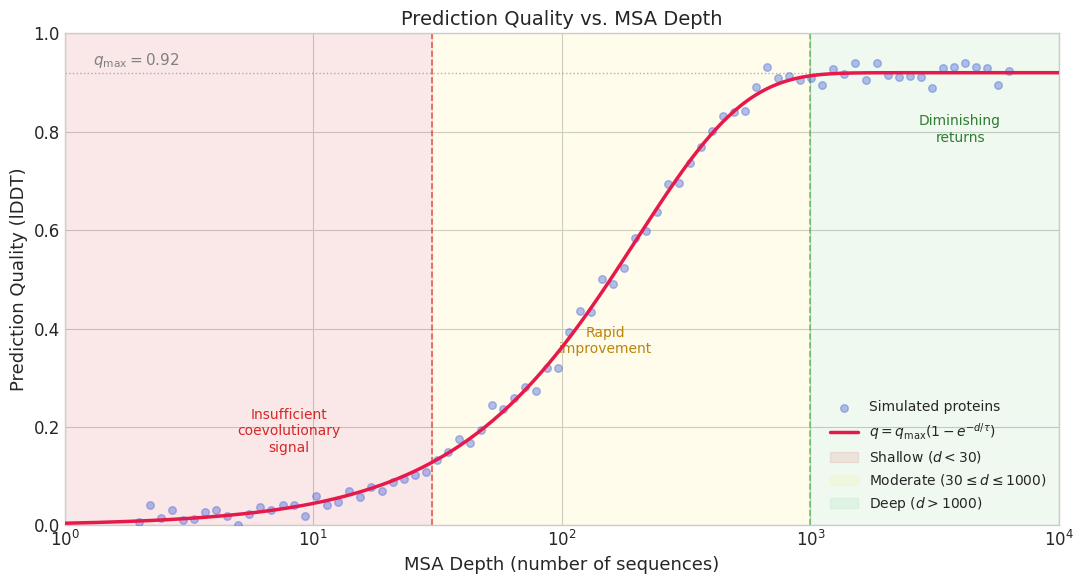

Parameters: q_max = 0.92, tau = 200.0
Quality at depth 10: 0.045
Quality at depth 100: 0.362
Quality at depth 1000: 0.914
Quality at depth 5000: 0.920


In [8]:
# --- Simulate prediction quality vs. MSA depth ---

q_max = 0.92     # asymptotic maximum lDDT
tau = 200.0      # characteristic depth
noise_std = 0.015  # observation noise

# MSA depths (log-spaced for visualization)
depths = np.logspace(0, 4, 500)  # from 1 to 10,000 sequences
quality_curve = q_max * (1 - np.exp(-depths / tau))

# Simulated data points with noise
np.random.seed(99)
sample_depths = np.logspace(0.3, 3.8, 80)
sample_quality = q_max * (1 - np.exp(-sample_depths / tau)) + np.random.randn(80) * noise_std
sample_quality = np.clip(sample_quality, 0, 1)

fig, ax = plt.subplots(figsize=(11, 6))

# Scatter points
ax.scatter(sample_depths, sample_quality, alpha=0.4, s=30, color='#4363d8',
           label='Simulated proteins', zorder=3)

# Theoretical curve
ax.plot(depths, quality_curve, '-', color='#e6194b', linewidth=2.5,
        label=r'$q = q_{\max}(1 - e^{-d/\tau})$', zorder=4)

# Shade regions
ax.axvspan(1, 30, alpha=0.10, color='#d62728', label='Shallow ($d < 30$)')
ax.axvspan(30, 1000, alpha=0.08, color='#ffe119', label='Moderate ($30 \leq d \leq 1000$)')
ax.axvspan(1000, 10000, alpha=0.08, color='#3cb44b', label='Deep ($d > 1000$)')

# Vertical threshold lines
ax.axvline(x=30, color='#d62728', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(x=1000, color='#3cb44b', linestyle='--', linewidth=1.2, alpha=0.7)

# Annotations
ax.annotate('Insufficient\ncoevolutionary\nsignal', xy=(8, 0.15), fontsize=10,
            ha='center', color='#d62728')
ax.annotate('Rapid\nimprovement', xy=(150, 0.35), fontsize=10,
            ha='center', color='#b8860b')
ax.annotate('Diminishing\nreturns', xy=(4000, 0.78), fontsize=10,
            ha='center', color='#2e7d32')

# Asymptote
ax.axhline(y=q_max, color='gray', linestyle=':', linewidth=1.0, alpha=0.6)
ax.text(1.3, q_max + 0.015, f'$q_{{\\max}} = {q_max}$', fontsize=11, color='gray')

ax.set_xscale('log')
ax.set_xlabel('MSA Depth (number of sequences)', fontsize=13)
ax.set_ylabel('Prediction Quality (lDDT)', fontsize=13)
ax.set_title('Prediction Quality vs. MSA Depth', fontsize=14)
ax.set_xlim(1, 10000)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()

print(f"Parameters: q_max = {q_max}, tau = {tau}")
print(f"Quality at depth 10: {q_max * (1 - np.exp(-10/tau)):.3f}")
print(f"Quality at depth 100: {q_max * (1 - np.exp(-100/tau)):.3f}")
print(f"Quality at depth 1000: {q_max * (1 - np.exp(-1000/tau)):.3f}")
print(f"Quality at depth 5000: {q_max * (1 - np.exp(-5000/tau)):.3f}")

The plot reveals the characteristic S-shaped (on a log scale) relationship between MSA depth and prediction quality:

- With fewer than ~30 sequences, the coevolutionary signal is too weak for reliable contact prediction. This is the regime where "orphan proteins" (those with no known homologs) present the greatest challenge.

- Between 30 and ~1000 sequences, each additional homolog provides substantial new information, and prediction quality improves rapidly.

- Beyond ~1000 sequences, the coevolutionary signal is largely saturated, and additional sequences provide diminishing returns.

AlphaFold2 addressed the shallow MSA problem through (a) template-based features, (b) learned MSA processing via the Evoformer, and (c) MSA subsampling strategies during training. Nevertheless, MSA depth remains one of the strongest predictors of model confidence (pLDDT).

---

## 8. Summary and Key Takeaways

### What we learned in this notebook

1. **Multiple Sequence Alignments (MSAs)** organize homologous protein sequences so that evolutionarily equivalent positions are aligned in columns. An MSA is a matrix $\mathbf{M} \in \{1, \dots, q\}^{N \times L}$.

2. **Sequence conservation**, measured by Shannon entropy $H_i = -\sum_a f_{a,i} \log_2 f_{a,i}$, identifies positions under evolutionary constraint. Low-entropy positions are structurally or functionally important.

3. **Coevolution** -- the correlated evolution of residue pairs in physical contact -- is the key insight that links sequence data to 3D structure. Mutual Information $MI(i,j)$ quantifies these correlations.

4. **Raw MI is noisy**: phylogenetic bias and transitive correlations produce false positives. The **APC correction** removes background noise. **Direct Coupling Analysis (DCA)** and the **Potts model** go further by disentangling direct from indirect couplings.

5. **Contact maps constrain 3D structure**: given enough true contacts, the protein fold can be approximately reconstructed through distance geometry and energy minimization.

6. **AlphaFold2 processes MSAs** through the Evoformer, which applies row-wise and column-wise attention to an MSA representation tensor of shape $(N_{\text{seq}}, N_{\text{res}}, 256)$, and produces a pair representation of shape $(N_{\text{res}}, N_{\text{res}}, 128)$ that encodes coevolutionary information for structure prediction.

7. **MSA depth matters**: prediction quality follows a saturating curve $q = q_{\max}(1 - e^{-d/\tau})$, with major improvements between 30 and 1000 sequences.

### The central equation connecting evolution to structure

$$
\text{Evolutionary constraints} \xrightarrow{\text{MSA}} \text{Coevolution patterns} \xrightarrow{\text{DCA/ML}} \text{Contact predictions} \xrightarrow{\text{Geometry}} \text{3D Structure}
$$

AlphaFold2 learns all three arrows end-to-end, but the fundamental information source remains the MSA.

### Coming up next

**Notebook 3** will explore how AlphaFold2 encodes the MSA and structural templates into its input representations -- the initial MSA features, pair features, and template features that feed into the Evoformer.

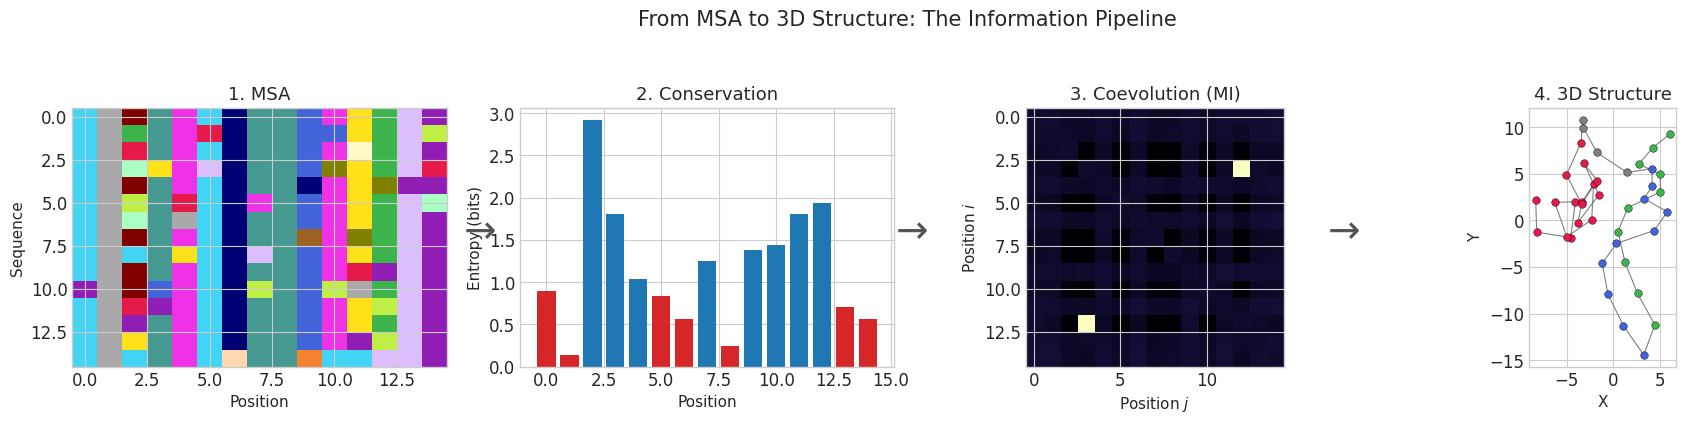

End of Notebook 2: MSAs and Evolutionary Information
Next: Notebook 3 -- Input Representations in AlphaFold2


In [9]:
# --- Visual summary: the pipeline from MSA to structure ---

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Panel 1: MSA (subset)
ax = axes[0]
ax.imshow(msa[:15, :15], aspect='auto', cmap=aa_cmap, norm=aa_norm, interpolation='nearest')
ax.set_title('1. MSA', fontsize=13)
ax.set_xlabel('Position', fontsize=11)
ax.set_ylabel('Sequence', fontsize=11)

# Panel 2: Conservation
ax = axes[1]
entropy_subset = entropy[:15]
colors_ent = ['#d62728' if h < 1.0 else '#1f77b4' for h in entropy_subset]
ax.bar(range(15), entropy_subset, color=colors_ent)
ax.set_title('2. Conservation', fontsize=13)
ax.set_xlabel('Position', fontsize=11)
ax.set_ylabel('Entropy (bits)', fontsize=11)

# Panel 3: Coevolution (MI)
ax = axes[2]
ax.imshow(mi_apc[:15, :15], cmap='magma', interpolation='nearest')
ax.set_title('3. Coevolution (MI)', fontsize=13)
ax.set_xlabel('Position $j$', fontsize=11)
ax.set_ylabel('Position $i$', fontsize=11)

# Panel 4: 3D Structure
ax = axes[3]
# Project 3D coords to 2D for a simple plot
ax.plot(coords_opt[:, 0], coords_opt[:, 1], '-', color='gray', linewidth=0.8)
for i in range(L_struct):
    ax.scatter(coords_opt[i, 0], coords_opt[i, 1],
               c=colors_struct[i], s=30, edgecolors='black', linewidths=0.3, zorder=5)
ax.set_title('4. 3D Structure', fontsize=13)
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)
ax.set_aspect('equal')

# Add arrows between panels
for i in range(3):
    fig.text(0.26 + i * 0.24, 0.5, r'$\rightarrow$', fontsize=28,
             ha='center', va='center', transform=fig.transFigure, color='#555555')

plt.suptitle('From MSA to 3D Structure: The Information Pipeline', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

print("End of Notebook 2: MSAs and Evolutionary Information")
print("Next: Notebook 3 -- Input Representations in AlphaFold2")